In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings('ignore')

**The dataset appears to contain various column with information about employee their work details salaries job title
and other related attributes heres quick overview of the columns**

work_year:the year the data was recorded

In [8]:
df = pd.read_csv('DS_Companies.csv')
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


In [10]:
df.drop(df[['Unnamed: 0','salary']],axis=1,inplace=True)

In [11]:
df.head()

,work_year,experience_level,employment_type,job_title,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,USD,150000,US,50,US,L


In [12]:
df['work_year'].unique()

array([2020, 2021, 2022])

In [13]:
df1 = df.groupby('work_year')['salary_in_usd'].mean().round(2)

In [14]:
df1

work_year
2020     95813.00
2021     99853.79
2022    124522.01
Name: salary_in_usd, dtype: float64

In [15]:
df1.index

Index([2020, 2021, 2022], dtype='int64', name='work_year')

In [16]:
df1.values

array([ 95813.  ,  99853.79, 124522.01])

In [17]:
data = {
    'work_year':df1.index,
    'average_salary':df1.values
}
df1=pd.DataFrame(data)
df1

,work_year,average_salary
0,2020,95813.00
1,2021,99853.79
2,2022,124522.01


In [18]:
df1['average_salary'] = (df1['average_salary']/1000).round(2)
df1

,work_year,average_salary
0,2020,95.81
1,2021,99.85
2,2022,124.52


<Axes: xlabel='work_year'>

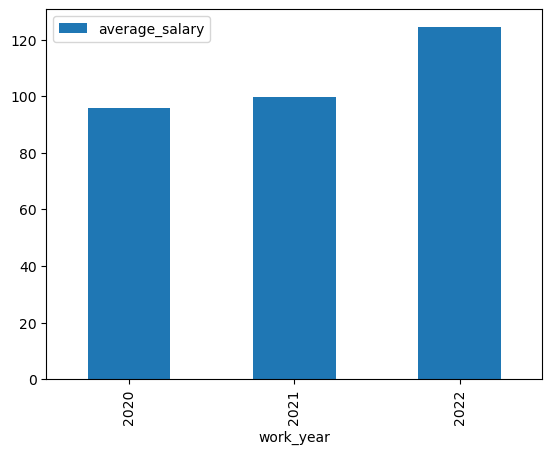

In [19]:
df1.plot(kind='bar',x='work_year',y='average_salary')

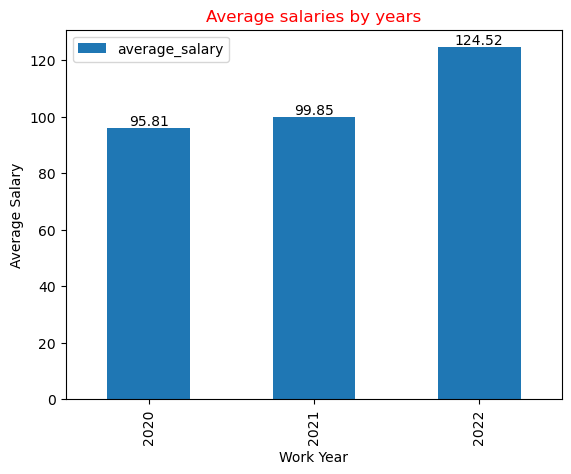

In [27]:
ax = df1.plot(kind='bar', x='work_year', y='average_salary', legend=True)

# Add labels on bars
ax.bar_label(ax.containers[0], labels=df1['average_salary'].map('{:.2f}'.format))

ax.legend(['average_salary'], loc='upper left')
plt.xlabel('Work Year')
plt.ylabel('Average Salary')
plt.title('Average salaries by years', color='red')

plt.show()

#  Remote work trend

In [28]:
df.head()

,work_year,experience_level,employment_type,job_title,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,USD,150000,US,50,US,L


In [30]:
df.remote_ratio.unique()

array([  0,  50, 100])

In [31]:
df2 = df.remote_ratio.value_counts()

In [32]:
df2

remote_ratio
100    381
0      127
50      99
Name: count, dtype: int64

In [33]:
values = df2.tolist()
values

[381, 127, 99]

In [35]:
labled = ['fully remote','No remote','Partially_remote']
labled
          

['fully remote', 'No remote', 'Partially_remote']

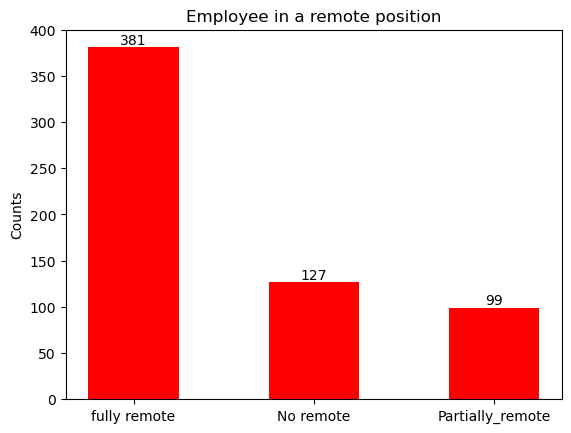

In [40]:
z = plt.bar(labled, values, width=0.5, color='red')

# Add labels on bars
plt.bar_label(z, labels=values)

plt.title('Employee in a remote position')
plt.ylabel('Counts')
plt.show()

In [41]:
df.head(1)

,work_year,experience_level,employment_type,job_title,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,EUR,79833,DE,0,DE,L


In [42]:
df.company_size.unique()

array(['L', 'S', 'M'], dtype=object)

In [49]:
df3 = df.company_size.value_counts()
df3

company_size
M    326
L    198
S     83
Name: count, dtype: int64